In [1]:
import numpy as np
import matplotlib.pyplot as plt


# AWS imports: Import Braket SDK modules
from braket.circuits import Circuit, Gate, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask
from braket.tracking import Tracker

from scipy.sparse.linalg import expm_multiply
from scipy.sparse import diags
from utils import *


In [2]:
tracker = Tracker().start()

In [ ]:
# the IonQ device
device = AwsDevice("arn:aws:braket:::device/qpu/ionq/ionQdevice")
supported_gates = device.properties.action['braket.ir.jaqcd.program'].supportedOperations
# print the supported gate set
print('Gate set supported by the IonQ device:\n', supported_gates)
print('\n') 

Recall the Hamiltonian embedding of the momentum operator when using the unary code.

We embed
$$
    \hat{P} = -\frac{i}{2h}\begin{pmatrix}
    0 & 1 & 0 & 0\\
    -1 & 0 & \ddots & 0\\
    0 & \ddots & 0 & 1 \\
    0 & 0 & -1 & 0
    \end{pmatrix}
$$
in the full Hamiltonian
$$
    H = \frac{1}{2h}\sum_{i=1}^{n} Y_i + R \left(Z_1 - Z_n - \sum_{i=1}^{n-1} Z_i Z_{i+1}\right).
$$

In [4]:
def sum_J_yz(n : int, J : np.ndarray) -> np.ndarray:
    # row of J is for Pauli Z, column is for Pauli Y
    # J_{i,j} is coefficient of Z_i Y_j
    assert n > 0
    assert J.shape == (n,n)

    dims = [2 ** i for i in range(n)]

    res = csc_matrix((2 ** n, 2 ** n))
    for i in range(n):
        for j in range(i):
            res += J[i,j] * tensor([identity(dims[n-i-1], format='csr'), PAULI_Z, identity(dims[i-j-1], format='csr'), PAULI_Y, identity(dims[j], format='csr')])
            
    for j in range(n):
        for i in range(j):
            res += J[i,j] * tensor([identity(dims[n-j-1], format='csr'), PAULI_Y, identity(dims[j-i-1], format='csr'), PAULI_Z, identity(dims[i], format='csr')])
            
    return res

In [5]:
# Returns the codewords using unary embedding
def get_codewords_1d_unary(n : int, periodic):
    
    codewords = []

    bitstring = [0 for k in range(n)]

    if periodic:
        for i in range(2 * n):

            codewords.append(np.copy(bitstring))

            bitstring[i % n] = 1 - bitstring[i % n]

    else:
        for i in range(n+1):

            codewords.append(np.copy(bitstring))

            if i < n:
                bitstring[i] = 1 - bitstring[i]
    return codewords

In [20]:
n = 14
h = 1 / n
R = 10
m = 3
T = 1.0
periodic_boundary_conditions = True

C = get_codewords_1d_unary(n, periodic=periodic_boundary_conditions)

if periodic_boundary_conditions:
    N = 2 * n

    J = np.zeros((n, n))
    for i in range(n):
        if i == 0:
            J[(i-1) % n, i] = 1
        else:
            J[(i-1) % n, i] = -1
    S_YZ = sum_J_yz(n, J)

    J = np.zeros((n,n))
    J[0, n-1] = 1
    for i in range(n-1):
        J[i+1,i] = -1
    
    H_penalty = sum_J_zz(n, J)
    H_full = S_YZ / (2 * h) + R * H_penalty
    
else:
    N = n+1
    S_Y = sum_y(n)
    h_coefficients = np.zeros(n)
    h_coefficients[0] = 1
    h_coefficients[-1] = -1
    J = np.zeros((n,n))
    for i in range(n-1):
        J[i+1,i] = -1
        
    H_penalty = sum_h_z(n, h_coefficients) + sum_J_zz(n, J)
    H_full = S_Y / (2 * h) + R * H_penalty


In [21]:
H_subspace = np.zeros((N, N), dtype=np.complex64)

for i in range(N):
    for j in range(N):
        H_subspace[i,j] = H_full[bitstring_to_int(C[i]), bitstring_to_int(C[j])]

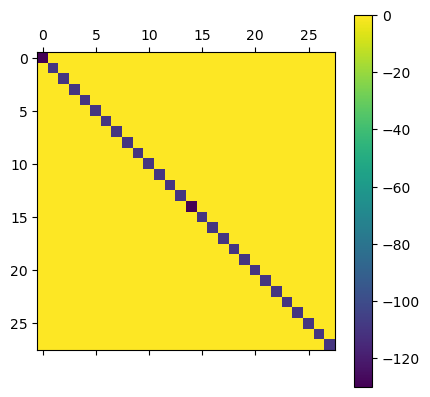

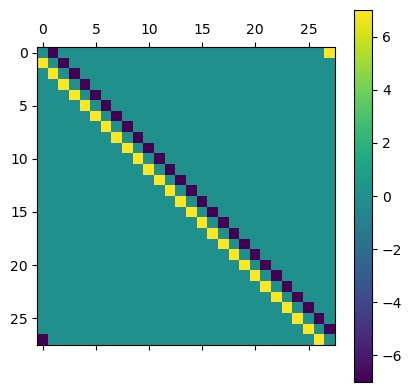

In [22]:
plt.matshow(H_subspace.real)
plt.colorbar()
plt.show()
plt.matshow(H_subspace.imag)
plt.colorbar()
plt.show()

We apply Trotterization of the Hamiltonian
$$
    H = \frac{1}{2h}\sum_{i=1}^{n} Y_i + R \left(Z_1 - Z_n - \sum_{i=1}^{n-1} Z_i Z_{i+1}\right)
$$

To evolve for time $T$, we have
$$
    e^{-iT H} \approx \left(\exp\left(-i\frac{T}{L} R \left(Z_1 - Z_n - \sum_{i=1}^{n-1} Z_i Z_{i+1}\right)\right) \exp\left(-i\frac{T}{L}\frac{1}{2h}\sum_{i=1}^{n} Y_i\right)\right)^{L}
$$

For simplicity, we will start with the initial state being a point mass at the left boundary, i.e.
$$
    \ket{\psi(0)} = \ket{00\dots 0},
$$
so no state preparation is necessary.

In [23]:
use_real_machine = False

if use_real_machine:
    device = AwsDevice("arn:aws:braket:::device/qpu/ionq/ionQdevice")
else:
    # set up device: Local Simulator
    device = LocalSimulator()

print(f"Using {device.name}")

Using StateVectorSimulator


In [24]:
def transport(n, T, L, R):
    h = 1 / n
    # Initial state preparation
    circuit = Circuit()

    for i in range(L):
        # sum of Pauli-y
        circuit.ry(range(n), T / (L * h))
    
        # penalty part
        circuit.rz(0, 2 * T * R / L)
        circuit.rz(n-1, -2 * T * R / L)
        for j in np.arange(0, n-1, 2):
            circuit.zz(j, j+1, - 2 * T * R / L)
        for j in np.arange(1, n-1, 2):
            circuit.zz(j, j+1, - 2 * T * R / L)
            
    return circuit

def decode_unary(n, bitstring):
    flips = 0
    first_flip = 0
    for i in range(n-1):
        if bitstring[i] != bitstring[i+1]:
            flips += 1
            first_flip = i
    
    if flips >= 2 or (bitstring[0] == 0 and flips == 1):
        return -1
    else:
        if flips == 0:
            if bitstring[0] == 0:
                return 0
            else:
                return n
        elif flips == 1:
            return first_flip + 1

In [25]:
circuit = transport(n, T, m, R = 7)

In [26]:
print(circuit)

print(f"Circuit depth: {circuit.depth}")

T   : |   0    |    1    |    2    |    3    |    4    |    5    |    6    |    7    |    8    |    9    |
                                                                                                          
q0  : -Ry(4.67)-Rz(4.67)--ZZ(-4.67)-Ry(4.67)--Rz(4.67)--ZZ(-4.67)-Ry(4.67)--Rz(4.67)--ZZ(-4.67)-----------
                          |                             |                             |                   
q1  : -Ry(4.67)-----------ZZ(-4.67)-ZZ(-4.67)-Ry(4.67)--ZZ(-4.67)-ZZ(-4.67)-Ry(4.67)--ZZ(-4.67)-ZZ(-4.67)-
                                    |                             |                             |         
q2  : -Ry(4.67)-ZZ(-4.67)-----------ZZ(-4.67)-Ry(4.67)--ZZ(-4.67)-ZZ(-4.67)-Ry(4.67)--ZZ(-4.67)-ZZ(-4.67)-
                |                                       |                             |                   
q3  : -Ry(4.67)-ZZ(-4.67)-ZZ(-4.67)-Ry(4.67)------------ZZ(-4.67)-ZZ(-4.67)-Ry(4.67)--ZZ(-4.67)-ZZ(-4.67)-
                          |          

In [27]:
num_shots = 100
task = device.run(circuit, shots=num_shots)

result = task.result()

counts = result.measurement_counts

In [28]:
def get_occurrences(n : int, measurements, num_shots : int):
    occurrences = np.zeros(n+1)
    # occurrences = np.zeros((4,n+1))
    bad_samples = 0
    for i in range(num_shots):
        bitstring = measurements[i]
                
        index = decode_unary(n, bitstring)
        if index >= 0:
            occurrences[index] += 1
                
    # print(f"Samples in codeword subspace: {int(np.sum(occurrences))} / {num_shots}")

    return occurrences

In [29]:
occurrences = get_occurrences(n, result.measurements, num_shots=num_shots)
dist = occurrences / np.sum(occurrences)

/tmp/ipykernel_20315/2744195178.py:2: RuntimeWarning: invalid value encountered in divide
  dist = occurrences / np.sum(occurrences)


In [59]:


psi_0 = np.zeros((n+1), dtype=np.complex64)
psi_0 = np.exp(-((np.linspace(-1,1, n+1) + 0.5)*3) ** 2)
psi_0 /= np.linalg.norm(psi_0)

# Transport Hamiltonian
H = diags([-1j * np.ones(n), 1j * np.ones(n)], [1, -1]) / (2 * h)
psi = expm_multiply(-1j * T * H, psi_0)
ideal_dist = np.abs(psi) ** 2

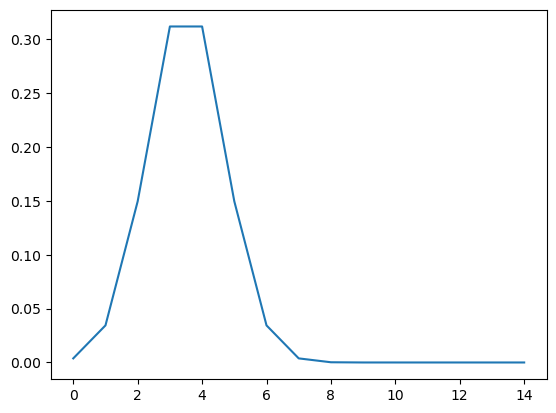

In [60]:
plt.plot(np.abs(psi_0)**2)

In [61]:
# psi_0 = np.zeros(2 ** n, dtype=np.complex64)
# psi_0[0] = 1

# psi = expm_multiply(-1j * T * H_full, psi_0)

# psi_subspace = np.zeros(n+1, dtype=np.complex128)

# bitstring = [0 for _ in range(n)]
# for i in range(n+1):

#     psi_subspace[i] = psi[bitstring_to_int(bitstring)]

#     if i < n:
#         bitstring[i] = 1 - bitstring[i]

# sim_dist = np.abs(psi_subspace) ** 2

# print(f"Leakage = {1 - np.sum(sim_dist)}")

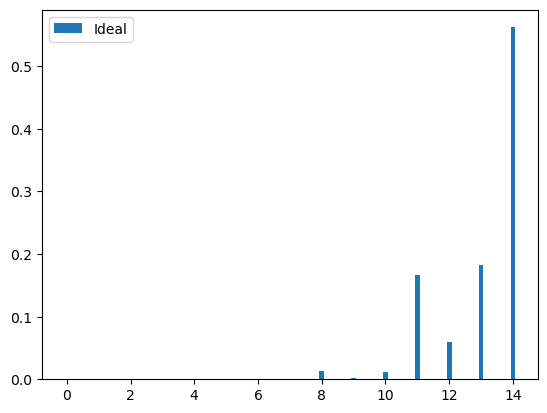

In [62]:
# plt.bar(np.array(range(n+1))-0.15, dist, width=0.15, label=f"{device.name}")
plt.bar(np.array(range(n+1)), ideal_dist, width=0.15, label="Ideal")
# plt.bar(np.array(range(n+1))+0.15, sim_dist, width=0.15, label="Full Hamiltonian")
plt.legend()
plt.show()

In [64]:
# M = 30
# TV_dist = []
# for m in range(1, M):
#     circuit = transport(n, T, m, R = 4)
#     num_shots = 1000
#     task = device.run(circuit, shots=num_shots)
#     result = task.result()
#     occurrences = get_occurrences(n, result.measurements, num_shots=num_shots)
#     dist = occurrences / np.sum(occurrences)

#     # Compare with ideal
#     H = diags([-1j * np.ones(n), 1j * np.ones(n)], [1, -1]) / (2 * h)
#     psi = expm_multiply(-1j * T * H, psi_0)
#     ideal_dist = np.abs(psi) ** 2
#     TV_dist.append(0.5 * np.sum(np.abs(dist - ideal_dist)))

# plt.plot(range(1, M), TV_dist)
# plt.xlabel("Number of Trotter steps")
# plt.ylabel("TV distance to ideal distribution")
# plt.show()